In [1]:
import sys
sys.path.append('../')
from utils_models import *

In [60]:
qbt = scqubits.Fluxonium(    EJ = 2.33,
                        EC = 0.69,
                        EL = 0.12,
                        flux = 0,
                        cutoff = 110,
                        truncated_dim = 11)
qbt.eigenvals()[3]-qbt.eigenvals()[0], qbt.eigenvals()[5]-qbt.eigenvals()[2], qbt.eigenvals()[4]-qbt.eigenvals()[1],  qbt.eigenvals()[1]-qbt.eigenvals()[0]



(2.8947132303123952, 2.893785107653048, 2.2670601729682587, 2.127502285282639)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

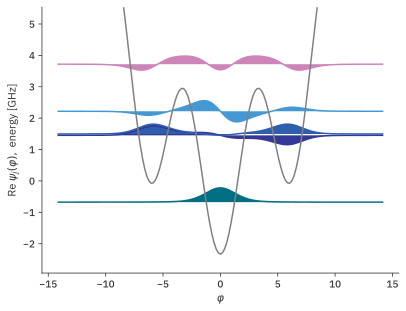

In [63]:
qbt.plot_wavefunction([0,1,2,3,4])

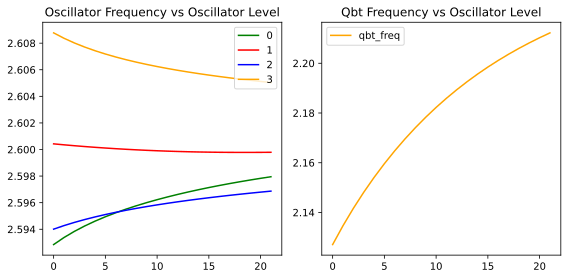

In [61]:
def plot_frequencies_qbt_osc(dressed_ener: Callable, ols):
    colors = ['green', 'red', 'blue', 'orange']
    # Create a figure and a set of subplots
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))  # Adjusted for better spacing
    # Second subplot for oscillator frequencies
    for ql in [0, 1, 2, 3]:
        osc_energies = []
        for ol in range(0, ols - 8):
            osc_energies.append(dressed_ener(ql, ol + 1) - dressed_ener(ql, ol))
        axs[0].plot(list(range(ols - 8)), osc_energies, label=f'{ql}', color=colors[ql])
    axs[0].set_title('Oscillator Frequency vs Oscillator Level')
    axs[0].legend()
    qbt_energies = []
    for ol in range(ols-8):
        qbt_energies.append(dressed_ener(1, ol) - dressed_ener(0, ol))
    axs[1].plot(list(range(ols-8)), qbt_energies, label=f'qbt_freq', color=colors[ql])
    axs[1].set_title('Qbt Frequency vs Oscillator Level')
    axs[1].legend()
    # Show the plots
    plt.tight_layout()  # Adjust the layout to make room for the legend
    plt.show()
    
ql = 20
max_ol = 30

system = FluxoniumOscillatorSystem(
    computaional_states = '1,2',
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 2.6,
    qubit_level = ql,
    osc_level = max_ol,
    g_strength = 0.1,
    products_to_keep=[[ql,ol] for ql in [0,1,2,3] for ol in range(max_ol)] 
    )


energies=  system.hilbertspace.eigenvals(system.qbt.truncated_dim * system.osc.truncated_dim )
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
ols = system.osc.truncated_dim
plot_frequencies_qbt_osc(dressed_ener, ols)

In [68]:
Er = 2.6
g =  0.1 
kappa =4e-2

max_ql = 5
max_ol = 3
system = FluxoniumOscillatorSystem(
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = Er,
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    kappa = kappa, 
    products_to_keep=[[ql, ol] for ql in range(5) for ol in range(3) ],
    computaional_states = '0,1',
    )


evals, evecs = system.hilbertspace.hamiltonian().eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)
def print_top_two_dressed_state(ql, ol):
    product_index = ql * system.osc.truncated_dim + ol
    overlaps_with_product_state = np.abs(overlap_matrix[:, product_index])
    sorted_indices = np.argsort(overlaps_with_product_state)[::-1]
    sorted_overlaps = overlaps_with_product_state[sorted_indices]
    print(f"product state q{ql} o{ol} is associated with {list(sorted_indices)[:2]} with overlap^2 {list(sorted_overlaps)[:2]}")
print_top_two_dressed_state(0,1) 
print_top_two_dressed_state(3, 0)
print_top_two_dressed_state(4 ,0)

tlist = np.linspace(0,1000,1000)
results = system.run_mesolve_parrallel(
    initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, 2))],
    tlist = tlist,
    c_ops=system.c_ops,
    drive_terms=[
        DriveTerm(
            driven_op =system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.qbt.n_operator) ),
            pulse_shape_func = square_pulse_with_rise_fall,
            pulse_shape_args={
                # 'w_d': system.hilbertspace.energy_by_bare_index((0,1))-system.hilbertspace.energy_by_bare_index((0,0)),
                'w_d': system.hilbertspace.energy_by_bare_index((3,0))-system.hilbertspace.energy_by_bare_index((2,0)),
                'amp':0.002,
                't_square':700,
            }
        )],
    e_ops=[
        system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension,i))) for i in [0,1,2,3,4,5,6,7]
    ],
)


product state q0 o1 is associated with [3, 4] with overlap^2 [0.9875867778694608, 0.1526214134154853]
product state q3 o0 is associated with [4, 3] with overlap^2 [0.9881054043174365, 0.15263884585832935]
product state q4 o0 is associated with [5, 6] with overlap^2 [0.9954733892410615, 0.0785644272522346]
 Total run time:  23.00s*] Elapsed 23.00s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 1000/1000 [00:00<00:00, 8921.39it/s]


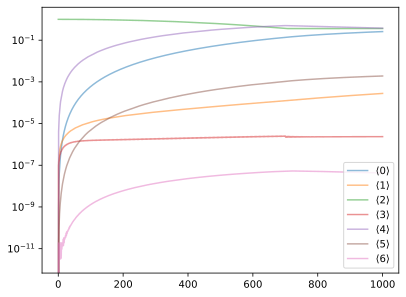

In [69]:
for i in range(7):
    plt.plot(tlist,results[0].expect[i],label=fr'$\langle{i}\rangle$',alpha = 0.5)

plt.legend()
plt.yscale('log')
